In [ ]:
# ==========================================
# TAHAP 1: PERSIAPAN LINGKUNGAN (ENVIRONMENT)
# ==========================================

# 1. Hubungkan Google Colab ke Google Drive Anda
from google.colab import drive
drive.mount('/content/drive')

# 2. Cek apakah GPU sudah aktif (Wajib pakai GPU agar training tidak berhari-hari)
# Pastikan di menu Colab: Runtime > Change runtime type > T4 GPU
!nvidia-smi

# 3. Install framework Ultralytics
!pip install ultralytics

Mounted at /content/drive
Sun Apr 12 16:36:59 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   41C    P8             12W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+---------------------

In [ ]:
# ==========================================
# TAHAP 2: PROSES TRAINING MODEL RT-DETR
# ==========================================

# 1. Import library yang dibutuhkan
import ultralytics
from ultralytics import RTDETR

# (Opsional) Cek apakah instalasi berhasil dan sistem siap
ultralytics.checks()

# 2. Memuat Arsitektur Dasar RT-DETR
# Kita menggunakan 'rtdetr-l.pt' (Varian Large) yang menyeimbangkan kecepatan dan akurasi
model = RTDETR('rtdetr-l.pt')

# 3. Memulai Proses Pelatihan (Training)
# Perhatikan: path data.yaml ini disesuaikan dengan foto Google Drive Anda sebelumnya
print("Mulai proses training RT-DETR...")

results = model.train(
    data='/content/drive/MyDrive/Skripsi_RTDETR/SampahPlastik-2/data.yaml', # Lokasi dataset
    epochs=50,       # Jumlah iterasi pembelajaran (Gunakan 50 dulu untuk tes awal)
    imgsz=640,       # Resolusi gambar (sesuai setting Resize di Roboflow)
    batch=16,        # Jumlah gambar yang diproses bersamaan dalam 1 waktu
    device=0,        # Memaksa Colab menggunakan GPU (GPU pertama = index 0)
    project='/content/drive/MyDrive/Skripsi_RTDETR/Hasil_Training', # Lokasi simpan hasil
    name='Percobaan_1' # Nama folder untuk hasil training ini
)

print("Proses training selesai! Hasil tersimpan di Google Drive.")

Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 43.1/112.6 GB disk)
Mulai proses training RT-DETR...
Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/Skripsi_RTDETR/SampahPlastik-2/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, 

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


       1/50      12.4G      1.355      0.569      2.464        230        640: 100% ━━━━━━━━━━━━ 50/50 1.5s/it 1:13
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 3.7s/it 7.3s
                   all         33        484      0.879      0.929      0.942      0.737

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size


/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


       2/50      13.1G     0.4387      0.524     0.1937        158        640: 100% ━━━━━━━━━━━━ 50/50 1.3s/it 1:03
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 2.7it/s 0.7s
                   all         33        484      0.844      0.864       0.87      0.654

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size


...

      48/50      11.9G     0.1488     0.2422    0.06739         46        640: 100% ━━━━━━━━━━━━ 50/50 1.3s/it 1:04
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 2.6it/s 0.8s
                   all         33        484      0.951      0.946      0.974      0.813

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size


/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


      49/50      12.3G      0.148     0.2395    0.06401         88        640: 100% ━━━━━━━━━━━━ 50/50 1.4s/it 1:09
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 1.9it/s 1.0s
                   all         33        484      0.961       0.95      0.974      0.808

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size


/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


      50/50      11.8G     0.1392     0.2303    0.05818         96        640: 100% ━━━━━━━━━━━━ 50/50 1.3s/it 1:05
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 2.6it/s 0.8s
                   all         33        484      0.956       0.95      0.976      0.812

50 epochs completed in 0.932 hours.
Optimizer stripped from /content/drive/MyDrive/Skripsi_RTDETR/Hasil_Training/Percobaan_1/weights/last.pt, 66.2MB
Optimizer stripped from /content/drive/MyDrive/Skripsi_RTDETR/Hasil_Training/Percobaan_1/weights/best.pt, 66.2MB

Validating /content/drive/MyDrive/Skripsi_RTDETR/Hasil_Training/Percobaan_1/weights/best.pt...
Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
rt-detr-l summary: 310 layers, 31,987,850 parameters, 0 gradients, 103.4 GFLOPs
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 1.7it/s 1.2s
                   all 

Membuat Grafik Akurasi (mAP50)...


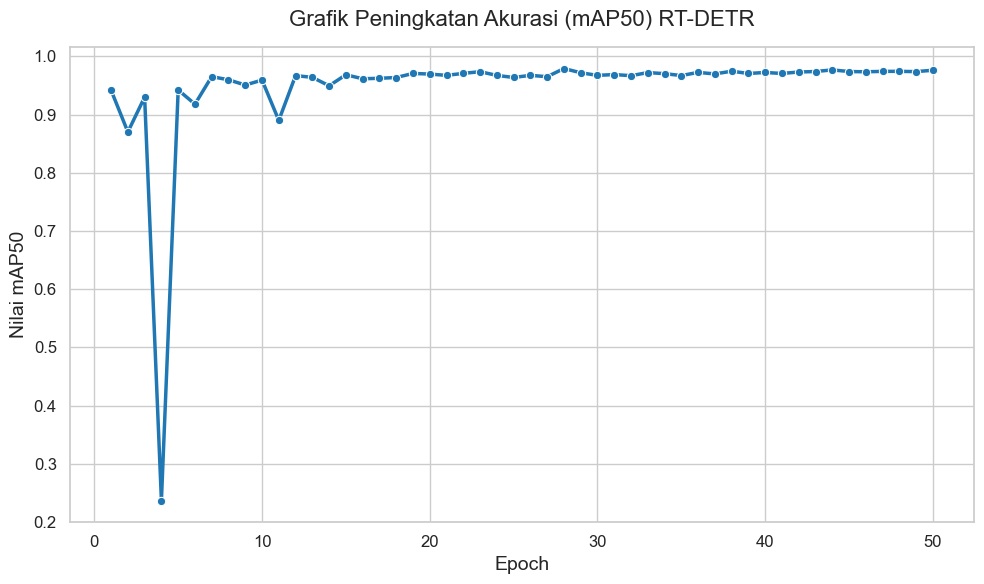

Membuat Grafik Training Loss (Classification)...


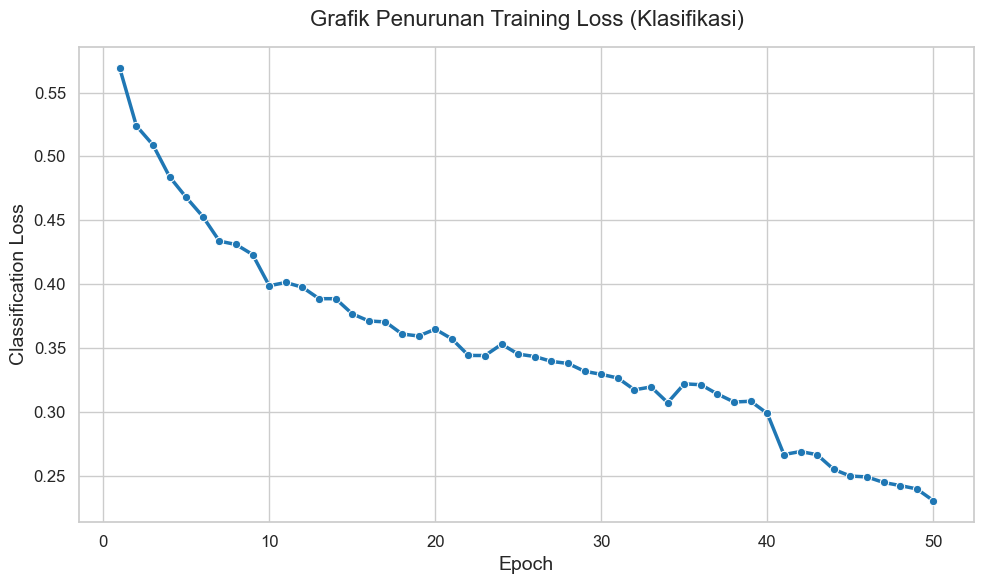

Membuat Grafik Validation Loss (Classification)...


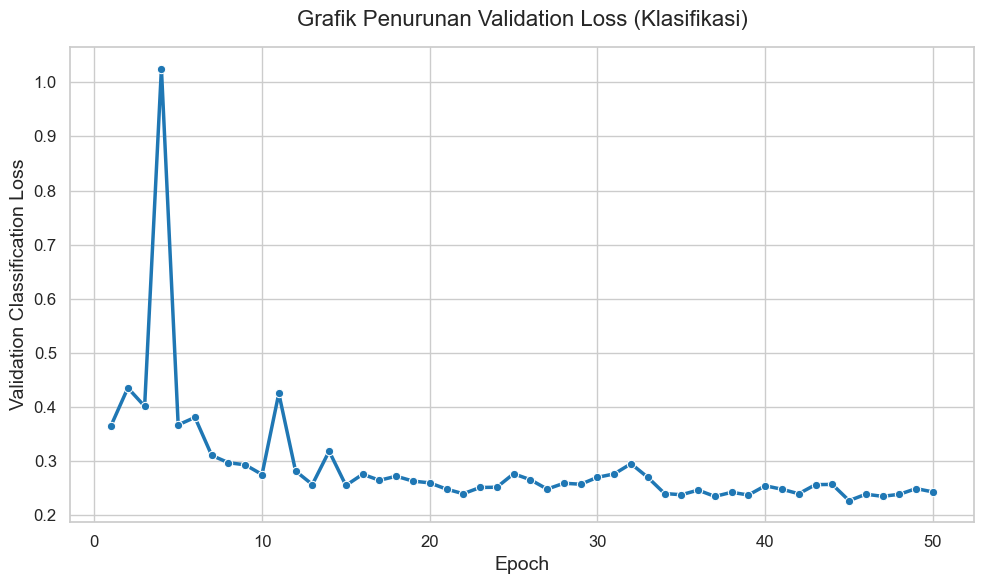

Membuat Grafik Presisi (Precision)...


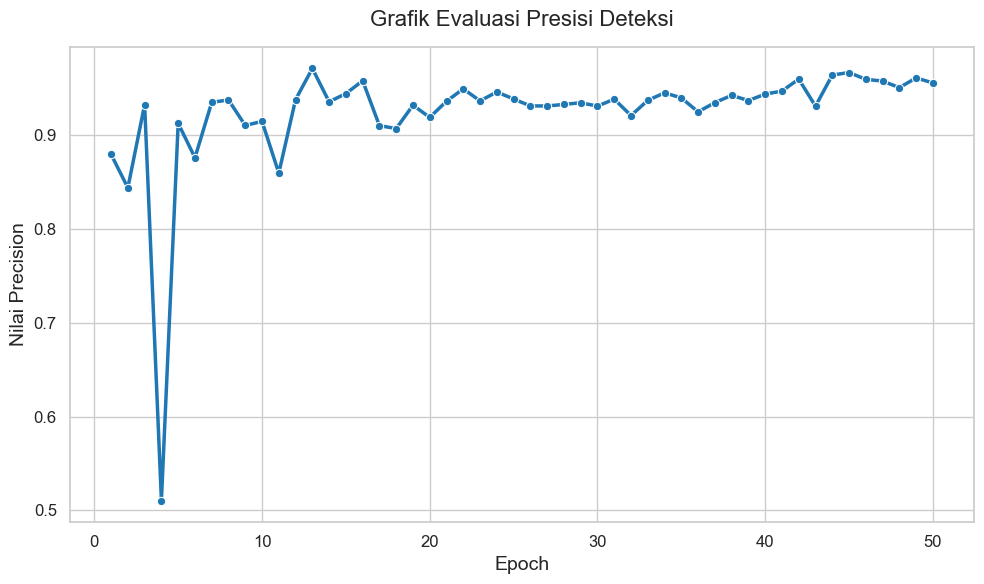

Semua grafik satuan berhasil dibuat dan disimpan di folder Percobaan_1!


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 1. Tentukan lokasi file results.csv Anda
# Pastikan path ini sesuai dengan folder penyimpanan hasil training Anda
csv_path = '/content/drive/MyDrive/Skripsi_RTDETR/Hasil_Training/Percobaan_1/results.csv'

# 2. Membaca data dan membersihkan spasi pada nama kolom
df = pd.read_csv(csv_path)
df.columns = df.columns.str.strip()

# 3. Mengatur gaya grafik agar terlihat elegan (gaya jurnal ilmiah)
sns.set_theme(style="whitegrid")

# 4. Fungsi khusus untuk menggambar dan menyimpan grafik secara individual
def buat_grafik_satuan(nama_kolom, judul_grafik, label_y, nama_file_simpan):
    # Cek apakah kolom ada di dalam file CSV
    if nama_kolom in df.columns:
        plt.figure(figsize=(10, 6)) # Ukuran kanvas (Lebar x Tinggi)

        # Membuat garis grafik dengan titik (marker 'o')
        sns.lineplot(x=df['epoch'], y=df[nama_kolom], marker='o', color='#1f77b4', linewidth=2.5)

        # Mengatur teks dan label
        plt.title(judul_grafik, fontsize=16, fontweight='bold', pad=15)
        plt.xlabel('Epoch', fontsize=14)
        plt.ylabel(label_y, fontsize=14)
        plt.xticks(fontsize=12)
        plt.yticks(fontsize=12)

        plt.tight_layout()

        # Menyimpan grafik ke dalam Google Drive (sebagai file PNG resolusi tinggi)
        save_dir = '/content/drive/MyDrive/Skripsi_RTDETR/Hasil_Training/Percobaan_1/'
        plt.savefig(os.path.join(save_dir, nama_file_simpan), dpi=300) # dpi=300 agar tidak pecah saat di-zoom

        # Menampilkan grafik di layar Colab
        plt.show()
    else:
        print(f"Kolom '{nama_kolom}' tidak ditemukan di results.csv")

# ==========================================
# 5. EKSEKUSI PEMBUATAN GRAFIK SATU PER SATU
# ==========================================

print("Membuat Grafik Akurasi (mAP50)...")
buat_grafik_satuan(
    nama_kolom='metrics/mAP50(B)',
    judul_grafik='Grafik Peningkatan Akurasi (mAP50) RT-DETR',
    label_y='Nilai mAP50',
    nama_file_simpan='grafik_mAP50_detail.png'
)

print("Membuat Grafik Training Loss (Classification)...")
buat_grafik_satuan(
    nama_kolom='train/cls_loss',
    judul_grafik='Grafik Penurunan Training Loss (Klasifikasi)',
    label_y='Classification Loss',
    nama_file_simpan='grafik_train_clsloss_detail.png'
)

print("Membuat Grafik Validation Loss (Classification)...")
buat_grafik_satuan(
    nama_kolom='val/cls_loss',
    judul_grafik='Grafik Penurunan Validation Loss (Klasifikasi)',
    label_y='Validation Classification Loss',
    nama_file_simpan='grafik_val_clsloss_detail.png'
)

print("Membuat Grafik Presisi (Precision)...")
buat_grafik_satuan(
    nama_kolom='metrics/precision(B)',
    judul_grafik='Grafik Evaluasi Presisi Deteksi',
    label_y='Nilai Precision',
    nama_file_simpan='grafik_precision_detail.png'
)

print("Semua grafik satuan berhasil dibuat dan disimpan di folder Percobaan_1!")